In [1]:
import numpy as np
import matplotlib.pyplot as plt

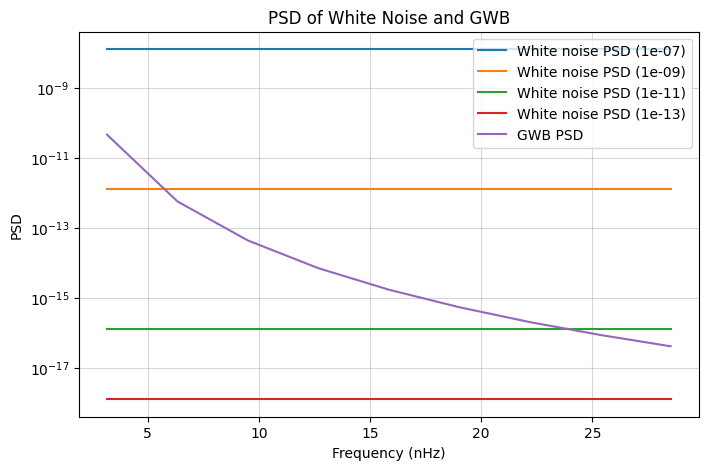

In [19]:
nfs = [1, 2, 3, 4, 5, 6, 7, 8, 9]
yr = 3600 * 24 * 365.25
Tobs = 10 * yr 
freqs = np.array(nfs) / Tobs

sigmas = [10**(-7), 10**(-9), 10**(-11), 10**(-13)]
efac = 1
log10_tnequad = -12
sigma_eff = [np.sqrt(efac**2 * sigma**2 + 10**(2 * log10_tnequad)) for sigma in sigmas]
dt = Tobs/(500-1) # Cadence
psd_wn = [2 * sigma_eff[i]**2 * dt * np.ones_like(freqs) for i in range(len(sigma_eff))]  # 2 * sigma**2 * delta_t


A = 10**(-14)
gamma = 13/3
fyr = 1/yr

Sh = (A**2 / (12*np.pi**2)) * (freqs/fyr)**(-gamma)
psd_gwb = Sh / (2*np.pi*freqs)**2

plt.figure(figsize=(8,5))
for i in range(len(psd_wn)):
    plt.plot(freqs*1e9, psd_wn[i], label=f'White noise PSD ({sigmas[i]})')
plt.plot(freqs*1e9, psd_gwb, label='GWB PSD')
plt.yscale('log')

plt.xlabel('Frequency (nHz)')
plt.ylabel('PSD')
plt.title('PSD of White Noise and GWB')

plt.grid(alpha = 0.5)
plt.legend()
plt.show()